<a href="https://colab.research.google.com/github/priyanshu60-pc/parcl-buyer-intelligence/blob/main/02_Clustering_Parcl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Load data
clients = pd.read_csv('/content/drive/MyDrive/parcl_project/clients.csv')
props   = pd.read_csv('/content/drive/MyDrive/parcl_project/properties.csv')

print("✓ Clients:", clients.shape)
print("✓ Properties:", props.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Clients: (2000, 12)
✓ Properties: (10000, 9)


In [6]:
# ── Cell 2: feature engineering ──────────────────────────────
# Compute age - fixed date parsing
# Standardize date format by replacing '/' with '-' to help pd.to_datetime parse mixed formats
clients['date_of_birth_standardized'] = clients['date_of_birth'].str.replace('/', '-', regex=False)
clients['age'] = pd.to_datetime('today').year - pd.to_datetime(
    clients['date_of_birth_standardized'], format='mixed', dayfirst=False
).dt.year

# Quick check
print("Age range:", clients['age'].min(), "to", clients['age'].max())
print("Sample ages:", clients['age'].head().tolist())

# Label encode categorical columns
le = LabelEncoder()
df = clients.copy()
for col in ['client_type','gender','acquisition_purpose','loan_applied','referral_channel']:
    df[col + '_enc'] = le.fit_transform(df[col])

# One-hot encode region + country
df = pd.get_dummies(df, columns=['region','country'], drop_first=True)

# Select features for clustering
features = ['age','satisfaction_score','client_type_enc',
            'acquisition_purpose_enc','loan_applied_enc','referral_channel_enc']
X = df[features]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Feature matrix ready:", X_scaled.shape)

Age range: 26 to 95
Sample ages: [58, 64, 67, 67, 50]
✓ Feature matrix ready: (2000, 6)


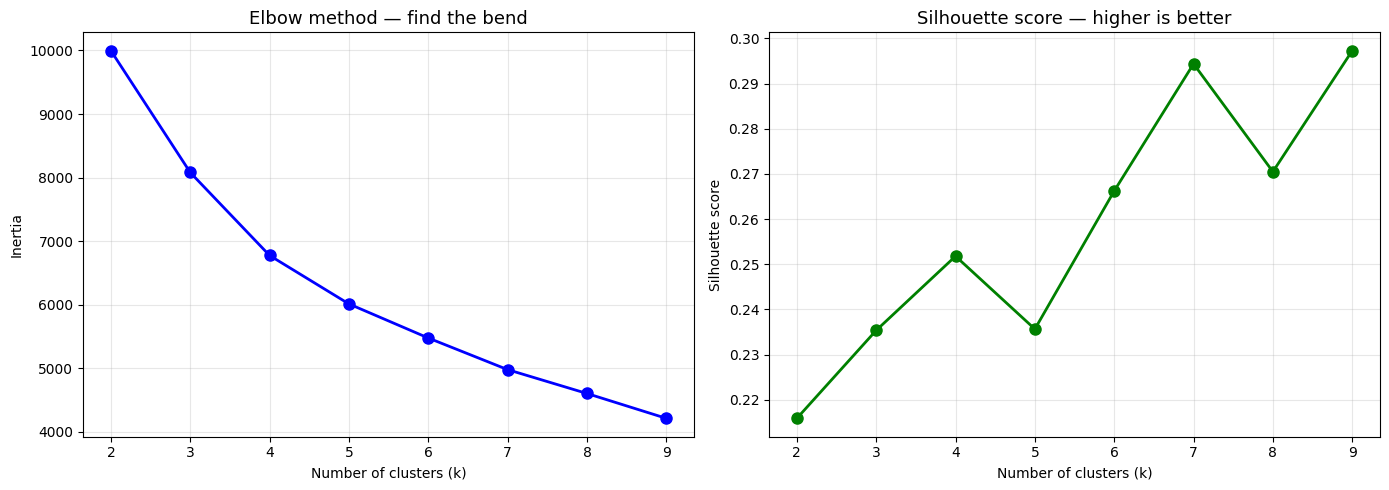


Silhouette scores:
  k=2: 0.2159
  k=3: 0.2354
  k=4: 0.2518
  k=5: 0.2357
  k=6: 0.2662
  k=7: 0.2944
  k=8: 0.2705
  k=9: 0.2973


In [7]:
# ── Cell 3: find optimal k ────────────────────────────────────
inertias, silhouettes = [], []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Elbow method — find the bend', fontsize=13)
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.grid(True, alpha=0.3)

ax2.plot(K, silhouettes, 'go-', linewidth=2, markersize=8)
ax2.set_title('Silhouette score — higher is better', fontsize=13)
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K, silhouettes):
    print(f"  k={k}: {s:.4f}")

In [8]:
# ── Cell 4: final K-Means with k=4 ───────────────────────────
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
clients['cluster'] = km_final.fit_predict(X_scaled)

# Label each cluster with a segment name
segment_names = {
    0: 'Global Investors',
    1: 'First-Time Buyers',
    2: 'Corporate Buyers',
    3: 'Luxury Investors'
}
clients['segment'] = clients['cluster'].map(segment_names)

print("Segment distribution:")
print(clients['segment'].value_counts())
print()
print("Sample:")
print(clients[['client_id','client_type','acquisition_purpose','segment']].head(10))

Segment distribution:
segment
First-Time Buyers    845
Global Investors     579
Corporate Buyers     473
Luxury Investors     103
Name: count, dtype: int64

Sample:
  client_id client_type acquisition_purpose            segment
0     C0001  Individual                Home   Corporate Buyers
1     C0002  Individual                Home  First-Time Buyers
2     C0003  Individual                Home   Corporate Buyers
3     C0004  Individual                Home  First-Time Buyers
4     C0005     Company          Investment   Luxury Investors
5     C0006  Individual                Home   Corporate Buyers
6     C0007  Individual          Investment   Global Investors
7     C0008  Individual                Home  First-Time Buyers
8     C0009  Individual          Investment   Global Investors
9     C0010  Individual          Investment   Global Investors


✓ Saved clients_clustered.csv to Drive


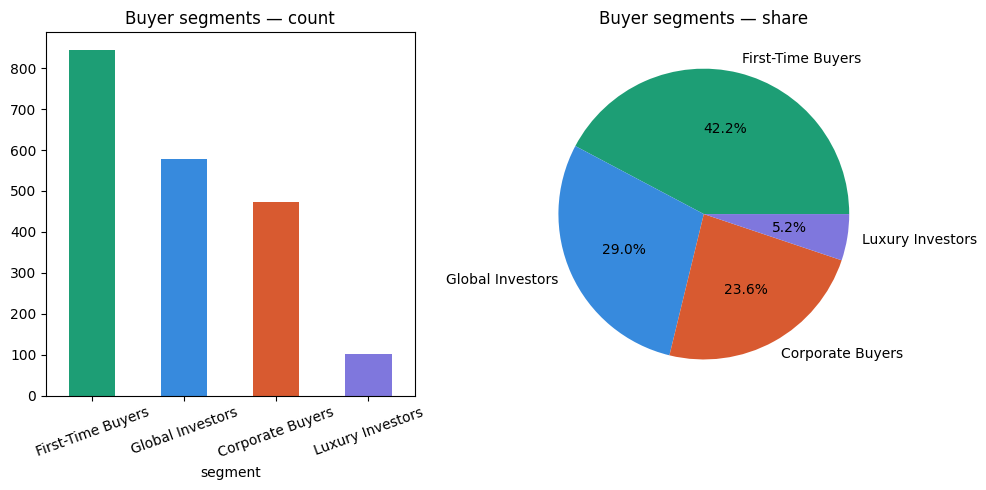

In [9]:
# ── Cell 5: save clustered data + quick visual ────────────────
# Save to Drive
clients.to_csv('/content/drive/MyDrive/parcl_project/clients_clustered.csv', index=False)
print("✓ Saved clients_clustered.csv to Drive")

# Plot segment distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
clients['segment'].value_counts().plot(kind='bar', color=['#1D9E75','#378ADD','#D85A30','#7F77DD'])
plt.title('Buyer segments — count')
plt.xticks(rotation=20)

plt.subplot(1, 2, 2)
clients['segment'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    colors=['#1D9E75','#378ADD','#D85A30','#7F77DD'])
plt.title('Buyer segments — share')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [10]:
# ── Cell 6: deep segment profiling ───────────────────────────
print("=" * 60)
print("SEGMENT PROFILES — KEY CHARACTERISTICS")
print("=" * 60)

profile_cols = ['acquisition_purpose', 'loan_applied',
                'client_type', 'gender', 'referral_channel',
                'satisfaction_score', 'age']

for seg in clients['segment'].unique():
    grp = clients[clients['segment'] == seg]
    print(f"\n── {seg.upper()} (n={len(grp)}) ──")
    print(f"  Avg age            : {grp['age'].mean():.1f} yrs")
    print(f"  Avg satisfaction   : {grp['satisfaction_score'].mean():.2f}/10")
    print(f"  Investment purpose : {(grp['acquisition_purpose']=='Investment').mean()*100:.1f}%")
    print(f"  Loan applied       : {(grp['loan_applied']=='Yes').mean()*100:.1f}%")
    print(f"  Corporate clients  : {(grp['client_type']=='Company').mean()*100:.1f}%")
    print(f"  Top referral       : {grp['referral_channel'].value_counts().index[0]}")
    print(f"  Top country        : {grp['country'].value_counts().index[0]}")
    print(f"  Top region         : {grp['region'].value_counts().index[0]}")

SEGMENT PROFILES — KEY CHARACTERISTICS

── CORPORATE BUYERS (n=473) ──
  Avg age            : 56.7 yrs
  Avg satisfaction   : 2.96/10
  Investment purpose : 0.0%
  Loan applied       : 100.0%
  Corporate clients  : 0.0%
  Top referral       : Website
  Top country        : USA
  Top region         : California

── FIRST-TIME BUYERS (n=845) ──
  Avg age            : 57.0 yrs
  Avg satisfaction   : 3.07/10
  Investment purpose : 0.0%
  Loan applied       : 0.0%
  Corporate clients  : 0.0%
  Top referral       : Website
  Top country        : USA
  Top region         : California

── LUXURY INVESTORS (n=103) ──
  Avg age            : 48.1 yrs
  Avg satisfaction   : 3.07/10
  Investment purpose : 35.0%
  Loan applied       : 41.7%
  Corporate clients  : 100.0%
  Top referral       : Website
  Top country        : USA
  Top region         : California

── GLOBAL INVESTORS (n=579) ──
  Avg age            : 55.7 yrs
  Avg satisfaction   : 3.02/10
  Investment purpose : 100.0%
  Loan applied  

                   avg_age  avg_satisfaction  pct_investment  pct_loan  \
segment                                                                  
Corporate Buyers      56.7               3.0             0.0     100.0   
First-Time Buyers     57.0               3.1             0.0       0.0   
Global Investors      55.7               3.0           100.0      38.0   
Luxury Investors      48.1               3.1            35.0      41.7   

                   pct_corporate  count  
segment                                  
Corporate Buyers             0.0    473  
First-Time Buyers            0.0    845  
Global Investors             0.0    579  
Luxury Investors           100.0    103  


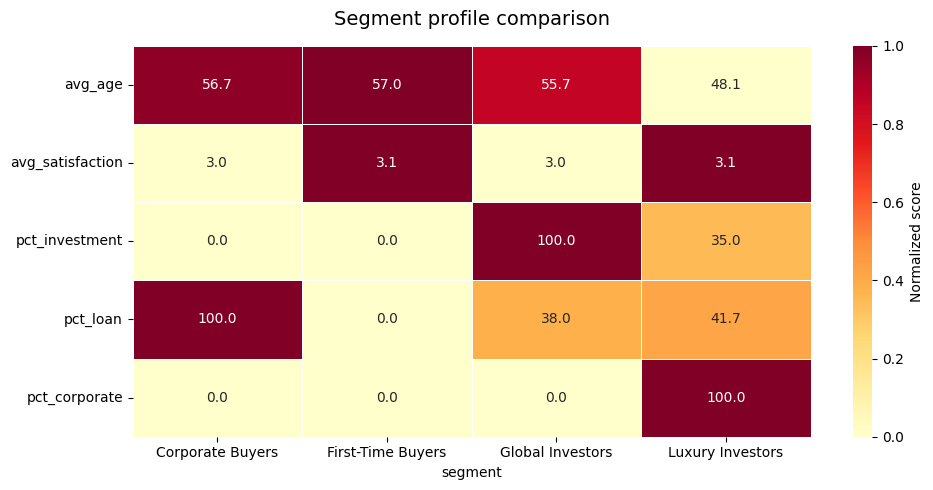

In [11]:
# ── Cell 7: segment comparison heatmap ───────────────────────
import pandas as pd
import numpy as np

summary = clients.groupby('segment').agg(
    avg_age            = ('age', 'mean'),
    avg_satisfaction   = ('satisfaction_score', 'mean'),
    pct_investment     = ('acquisition_purpose', lambda x: (x=='Investment').mean()*100),
    pct_loan           = ('loan_applied', lambda x: (x=='Yes').mean()*100),
    pct_corporate      = ('client_type', lambda x: (x=='Company').mean()*100),
    count              = ('client_id', 'count')
).round(1)

print(summary)

# Heatmap (normalized)
plt.figure(figsize=(10, 5))
heat_data = summary.drop(columns='count')
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

sns.heatmap(heat_norm.T, annot=heat_data.T, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Normalized score'})
plt.title('Segment profile comparison', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

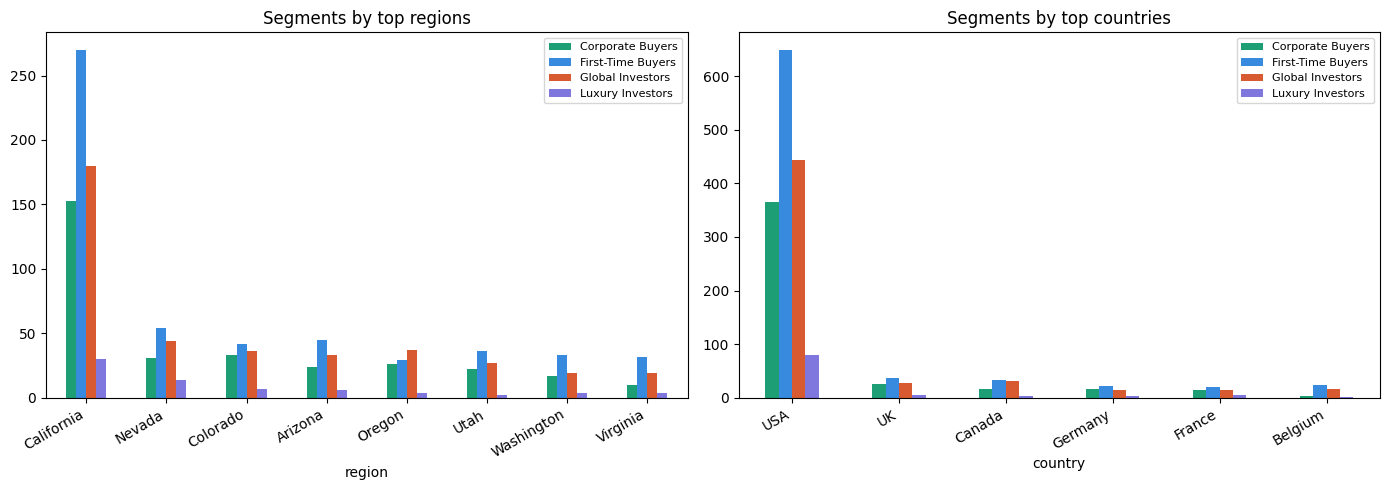

In [12]:
# ── Cell 8: geographic distribution per segment ──────────────
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
geo = clients.groupby(['region', 'segment']).size().unstack(fill_value=0)
top_regions = clients['region'].value_counts().head(8).index
geo.loc[top_regions].plot(kind='bar', ax=plt.gca(),
    color=['#1D9E75','#378ADD','#D85A30','#7F77DD'])
plt.title('Segments by top regions')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()

plt.subplot(1, 2, 2)
country_seg = clients.groupby(['country','segment']).size().unstack(fill_value=0)
top_countries = clients['country'].value_counts().head(6).index
country_seg.loc[top_countries].plot(kind='bar', ax=plt.gca(),
    color=['#1D9E75','#378ADD','#D85A30','#7F77DD'])
plt.title('Segments by top countries')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()

plt.show()

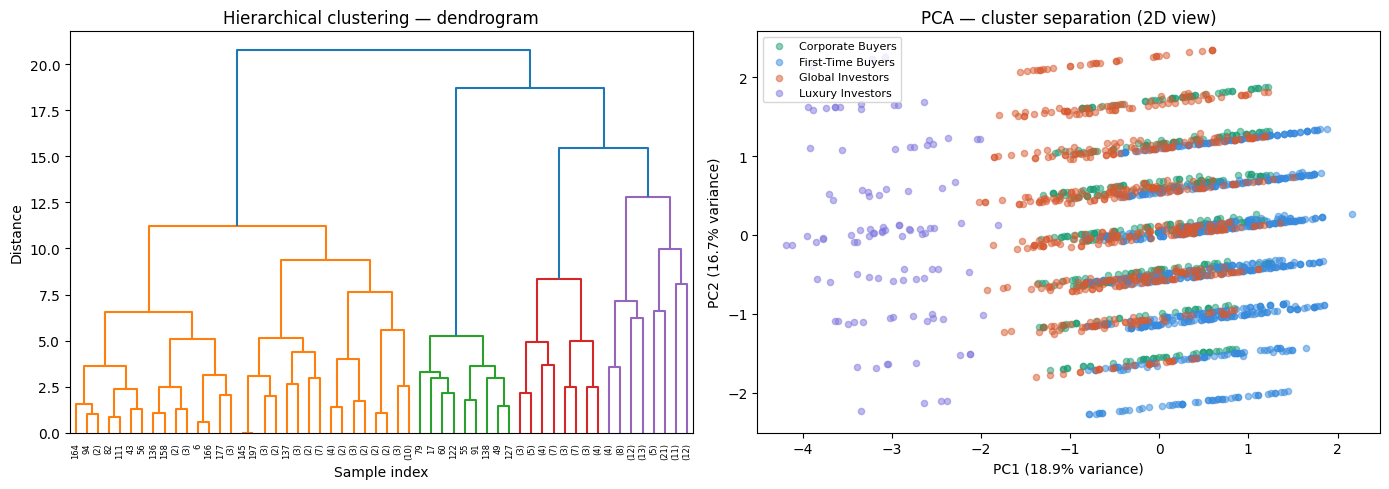

In [13]:
# ── Cell 9: hierarchical clustering validation ────────────────
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

# Use a sample of 200 rows for dendrogram (full 2000 is too dense)
sample_idx = np.random.choice(len(X_scaled), 200, replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
dendrogram(linked, truncate_mode='level', p=5,
           color_threshold=0.7*max(linked[:,2]))
plt.title('Hierarchical clustering — dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')

# PCA scatter to visualize clusters in 2D
plt.subplot(1, 2, 2)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
colors = ['#1D9E75','#378ADD','#D85A30','#7F77DD']
seg_list = ['Corporate Buyers','First-Time Buyers','Global Investors','Luxury Investors']

for i, seg in enumerate(seg_list):
    mask = clients['segment'] == seg
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=seg, alpha=0.5, s=20)

plt.title('PCA — cluster separation (2D view)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
# ── Cell 10: final summary export ────────────────────────────
summary_final = clients.groupby('segment').agg(
    count              = ('client_id', 'count'),
    pct_of_total       = ('client_id', lambda x: f"{len(x)/len(clients)*100:.1f}%"),
    avg_age            = ('age', lambda x: round(x.mean(), 1)),
    avg_satisfaction   = ('satisfaction_score', lambda x: round(x.mean(), 2)),
    pct_investment     = ('acquisition_purpose', lambda x: f"{(x=='Investment').mean()*100:.1f}%"),
    pct_loan           = ('loan_applied', lambda x: f"{(x=='Yes').mean()*100:.1f}%"),
    top_country        = ('country', lambda x: x.value_counts().index[0]),
    top_referral       = ('referral_channel', lambda x: x.value_counts().index[0])
).reset_index()

print("\n FINAL SEGMENT SUMMARY TABLE")
print("=" * 80)
print(summary_final.to_string(index=False))

# Save summary
summary_final.to_csv('/content/drive/MyDrive/parcl_project/segment_summary.csv', index=False)
print("\n✓ Saved segment_summary.csv to Drive")
print("✓ Clustering notebook COMPLETE")


 FINAL SEGMENT SUMMARY TABLE
          segment  count pct_of_total  avg_age  avg_satisfaction pct_investment pct_loan top_country top_referral
 Corporate Buyers    473        23.6%     56.7              2.96           0.0%   100.0%         USA      Website
First-Time Buyers    845        42.2%     57.0              3.07           0.0%     0.0%         USA      Website
 Global Investors    579        28.9%     55.7              3.02         100.0%    38.0%         USA      Website
 Luxury Investors    103         5.1%     48.1              3.07          35.0%    41.7%         USA      Website

✓ Saved segment_summary.csv to Drive
✓ Clustering notebook COMPLETE
